In [28]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [29]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [30]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
df

,id,epochs,error,rmse,mae,r2,model
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test
...,...,...,...,...,...,...,...
471,scmace,40,train_force,484.112120,337.015408,0.969717,model_rnd_e_scmace_lr0.0001_40_10_test
472,scmace_nofe8b4,90,test_energy,188.963887,116.325404,0.752811,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
473,scmace_nofe8b4,90,train_energy,158.415401,90.712991,0.813950,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
474,scmace_nofe8b4,90,test_force,508.495849,287.577999,0.967233,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test


In [31]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')
#matpes_nofe8b4_freeze = df.query('id == "matpes_nofe8b4_freeze"')
matpes_nofe8b4_freeze4 = df.query('id == "matpes_nofe8b4_freeze_4"')
matpes_nofe8b4_freeze6 = df.query('id == "matpes_nofe8b4_freeze_6"')

MAE and RMSE for energy

In [32]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [33]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [34]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['rmse'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [35]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [36]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

In [37]:
#f.plot_global_error([matpes, matpes_nofe8b4], ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

Comparison between fine tuning and freeze tuning

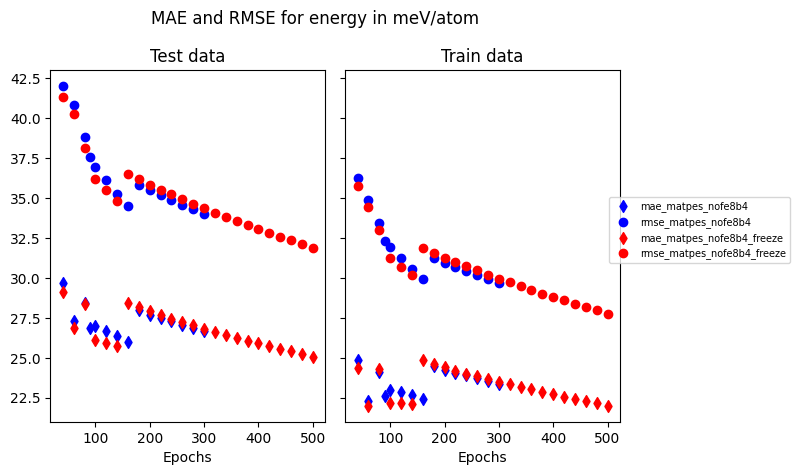

In [38]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'energy')

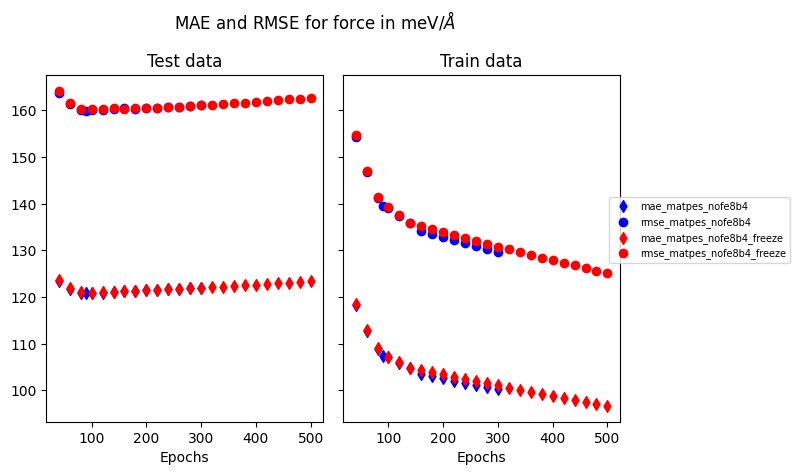

In [39]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'force')

In [40]:
#matpes_nofe8b4_freeze6

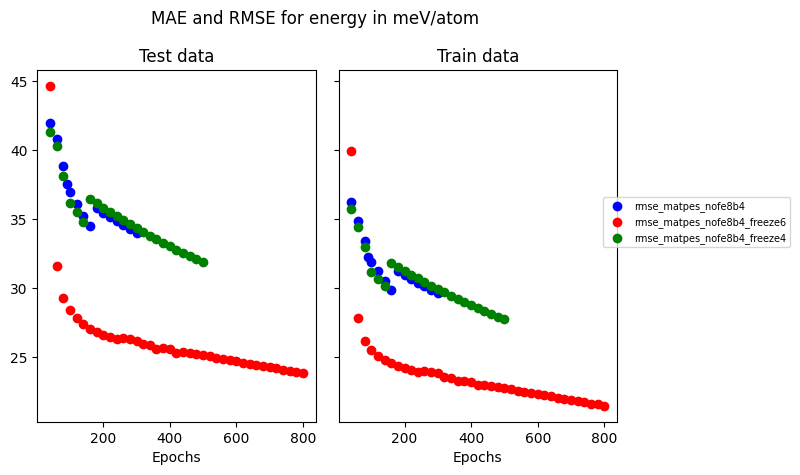

In [41]:
error_type = ['rmse']
value = 'energy'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

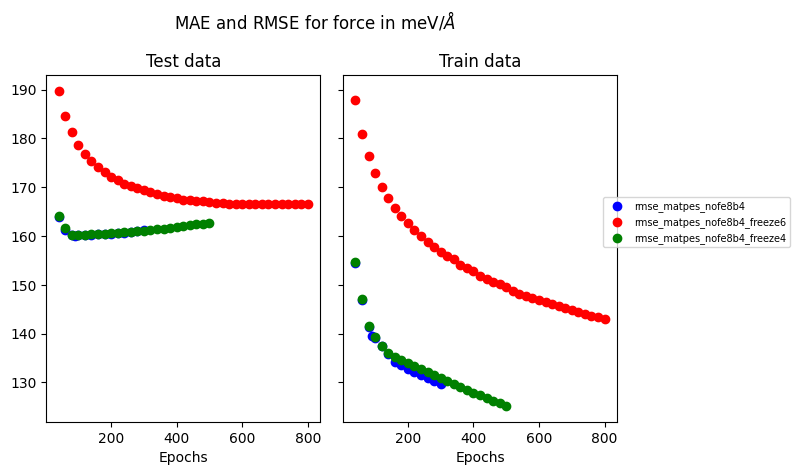

In [42]:
error_type = ['rmse']
value = 'force'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

In [43]:
#err_comparison = pd.concat([matpes_nofe8b4.query('epochs == 80'),matpes_nofe8b4_freeze.query('epochs == 80')])
err_comparison = pd.concat([matpes_nofe8b4, matpes_nofe8b4_freeze4])
#err_comparison = err_comparison.drop(columns=['epochs'])
#err_comparison

In [44]:
#err_comparison.query('error == ["test_energy","train_energy"]')
err_comparison.query('error == "test_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
156,matpes_nofe8b4_freeze_4,500,test_energy,31.873304,25.064329,0.992967,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_5...
264,matpes_nofe8b4_freeze_4,480,test_energy,32.103122,25.227115,0.992865,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
324,matpes_nofe8b4_freeze_4,460,test_energy,32.338331,25.392536,0.992761,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
164,matpes_nofe8b4_freeze_4,440,test_energy,32.567227,25.555282,0.992658,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
188,matpes_nofe8b4_freeze_4,420,test_energy,32.801959,25.719692,0.992551,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
364,matpes_nofe8b4_freeze_4,400,test_energy,33.043777,25.885693,0.992441,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
196,matpes_nofe8b4_freeze_4,380,test_energy,33.291773,26.059931,0.992327,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
452,matpes_nofe8b4_freeze_4,360,test_energy,33.545708,26.241595,0.992210,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
288,matpes_nofe8b4_freeze_4,340,test_energy,33.806829,26.425562,0.992088,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
32,matpes_nofe8b4,300,test_energy,34.019674,26.677932,0.991988,model_rnd_e_matpes_nofe8b4_lr0.0001_300_10_test


In [45]:
err_comparison.query('error == "test_force"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
50,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
18,matpes_nofe8b4,80,test_force,160.120801,120.835291,0.996751,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
66,matpes_nofe8b4,100,test_force,160.140061,120.888473,0.996750,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
122,matpes_nofe8b4,120,test_force,160.169780,120.942947,0.996749,model_rnd_e_matpes_nofe8b4_lr0.0001_120_10_test
350,matpes_nofe8b4_freeze_4,100,test_force,160.209902,120.972761,0.996747,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1...
114,matpes_nofe8b4,140,test_force,160.266164,121.057922,0.996745,model_rnd_e_matpes_nofe8b4_lr0.0001_140_10_test
170,matpes_nofe8b4_freeze_4,120,test_force,160.268819,121.041607,0.996745,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1...
202,matpes_nofe8b4_freeze_4,80,test_force,160.288844,120.990770,0.996744,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_8...
102,matpes_nofe8b4,180,test_force,160.335569,121.354660,0.996742,model_rnd_e_matpes_nofe8b4_lr0.0001_180_10_test
374,matpes_nofe8b4_freeze_4,160,test_force,160.356273,121.315772,0.996741,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1...


In [46]:
err_comparison.query('error == ["test_force","train_force"]')

,id,epochs,error,rmse,mae,r2,model
14,matpes_nofe8b4,220,test_force,160.571648,121.569571,0.996733,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
15,matpes_nofe8b4,220,train_force,132.189518,102.116622,0.997770,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
18,matpes_nofe8b4,80,test_force,160.120801,120.835291,0.996751,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
19,matpes_nofe8b4,80,train_force,141.337187,108.850125,0.997451,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
26,matpes_nofe8b4,240,test_force,160.698383,121.681674,0.996727,model_rnd_e_matpes_nofe8b4_lr0.0001_240_10_test
...,...,...,...,...,...,...,...
443,matpes_nofe8b4_freeze_4,60,train_force,147.097687,113.038198,0.997239,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_6...
454,matpes_nofe8b4_freeze_4,360,test_force,161.511501,122.373914,0.996694,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
455,matpes_nofe8b4_freeze_4,360,train_force,129.044649,99.710973,0.997875,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_3...
458,matpes_nofe8b4_freeze_4,220,test_force,160.618121,121.578755,0.996731,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_2...


In [47]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [48]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [49]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [50]:
df_config.query('id == "matpes" & epochs == 100')

,id,epochs,config,n_configs,mae,rmse,error,model
126,matpes,100,Fe12B3Si3,48,72.772737,73.184691,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
127,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
128,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
129,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
130,matpes,100,Fe8B4,8,115.094036,115.104171,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
131,matpes,100,Fe12B3Si3,132,72.800135,73.055497,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
132,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
133,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
134,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
135,matpes,100,Fe8B4,44,173.979772,419.412618,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [51]:
df.query('id == "matpes" & epochs == 100')

,id,epochs,error,rmse,mae,r2,model
60,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
61,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
62,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
63,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test


In [52]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

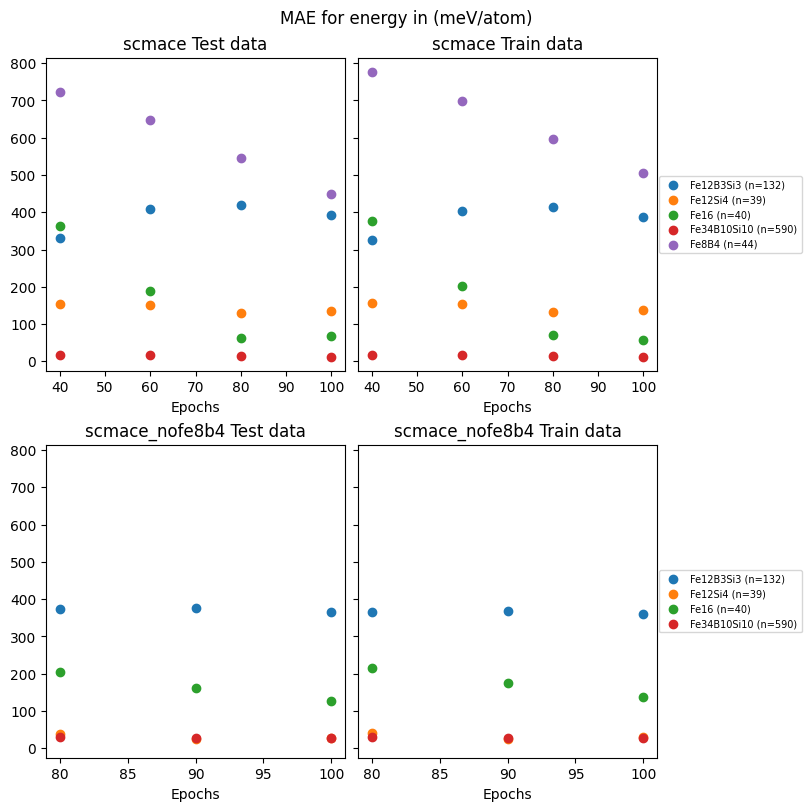

In [53]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

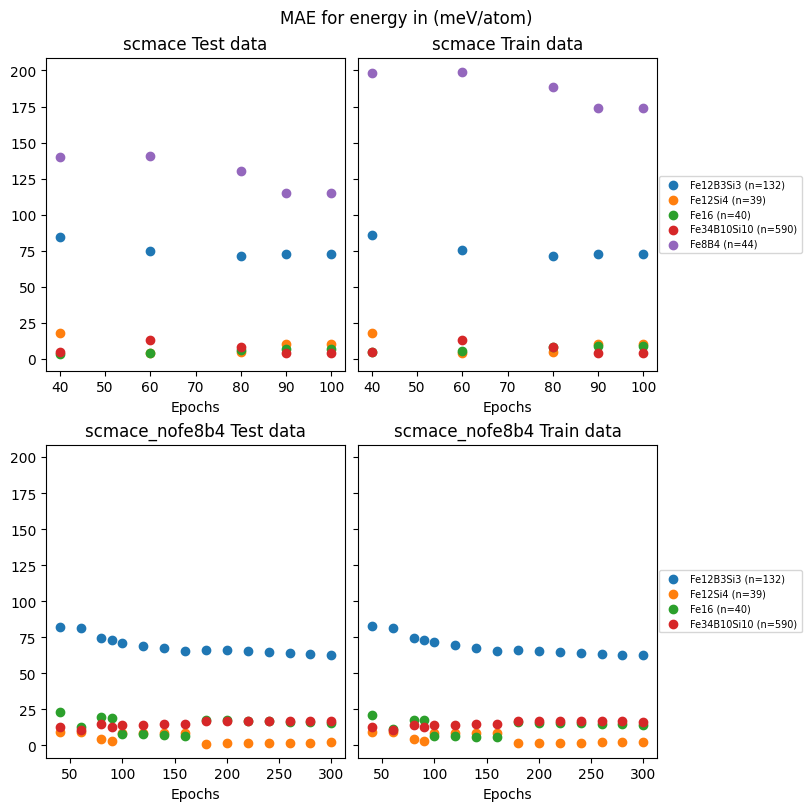

In [54]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')